# Statistical Inference — Practice Notebook

Companion practice notebook to the **Statistical Inference Study Notes**. Each section has:
- A short recap + worked example
- One or more **"Your Turn"** exercises with a `# TODO` for you to fill in
- A solution cell right after (try the exercise yourself first before peeking!)

**Topics covered:**
1. Probability distributions
2. Population vs. sample
3. Sampling distribution & the Central Limit Theorem
4. Estimation (bias, consistency)
5. Confidence intervals
6. Hypothesis testing
7. Final mini-project using the real Auto MPG dataset

Run cells top to bottom — later sections depend on variables defined earlier.


## 0. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
plt.rcParams['figure.figsize'] = (9, 4.5)


## 1. Probability Distributions

Let's visualize the PDF/PMF and CDF of the most common distributions, and practice computing
probabilities from them using `scipy.stats`.

### The math

For a **discrete** random variable, the PMF gives exact probabilities that must sum to 1:

$$
P(X = k) = p(k), \qquad \sum_k p(k) = 1
$$

For a **continuous** random variable, the PDF gives density (not probability directly) —
probability comes from the *area under the curve* over a range:

$$
P(a \le X \le b) = \int_a^b f(x)\,dx, \qquad \int_{-\infty}^{\infty} f(x)\,dx = 1
$$

The **CDF** is the running total up to a point, and works identically for both types:

$$
F(x) = P(X \le x)
$$

**The Normal distribution**, specifically, has this PDF:

$$
f(x) = \frac{1}{\sigma\sqrt{2\pi}} \, e^{-\frac{(x-\mu)^2}{2\sigma^2}}
$$

Every Normal-based method later in this notebook (z-scores, t-tests, confidence intervals)
is built directly on this formula.


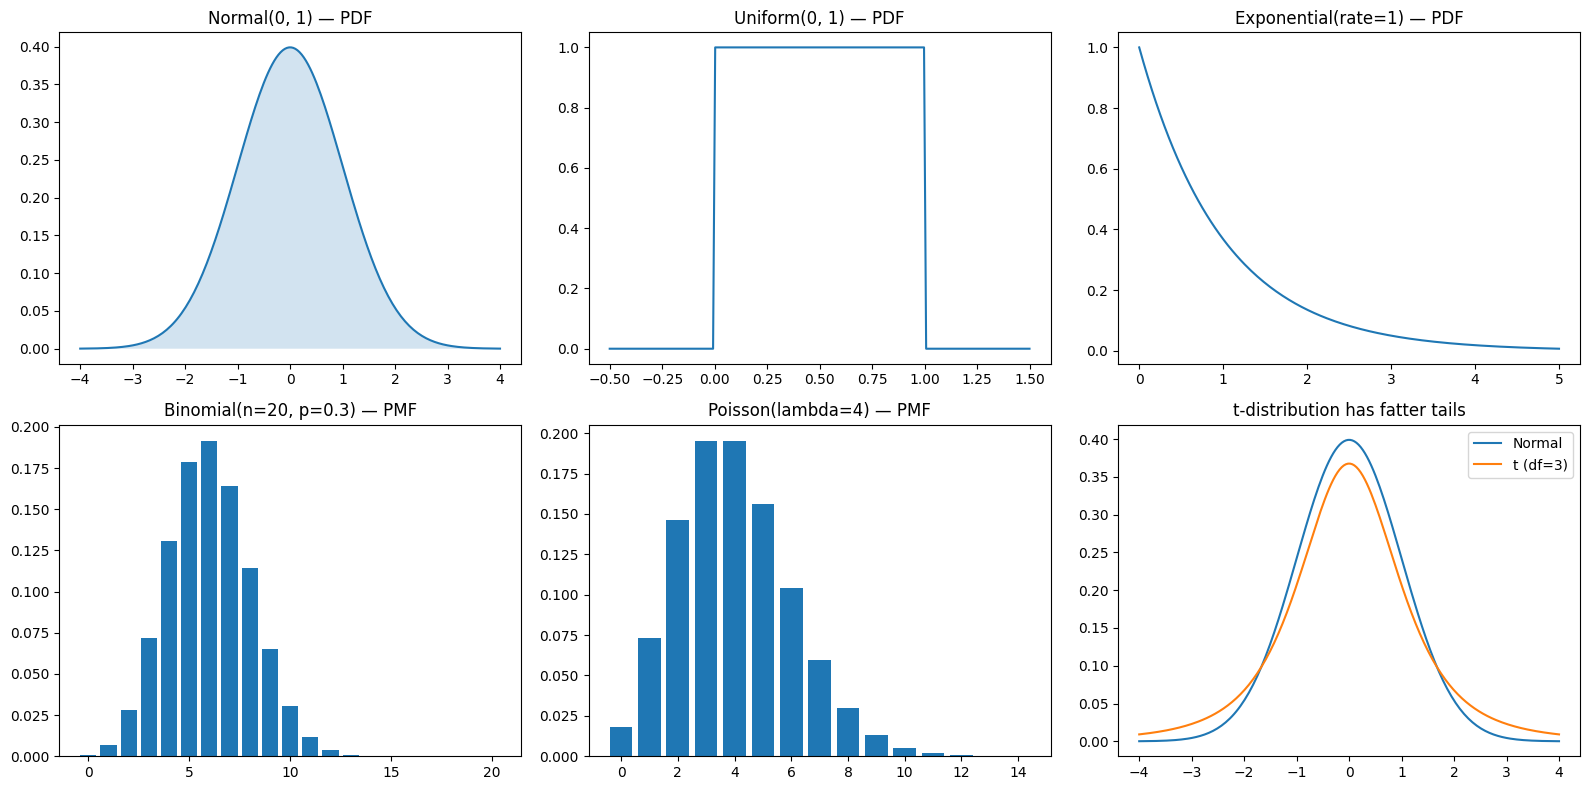

In [2]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))

# Normal
x = np.linspace(-4, 4, 200)
axes[0,0].plot(x, stats.norm.pdf(x, loc=0, scale=1))
axes[0,0].set_title("Normal(0, 1) — PDF")
axes[0,0].fill_between(x, stats.norm.pdf(x, 0, 1), alpha=0.2)

# Uniform
x = np.linspace(-0.5, 1.5, 200)
axes[0,1].plot(x, stats.uniform.pdf(x, loc=0, scale=1))
axes[0,1].set_title("Uniform(0, 1) — PDF")

# Exponential
x = np.linspace(0, 5, 200)
axes[0,2].plot(x, stats.expon.pdf(x, scale=1))
axes[0,2].set_title("Exponential(rate=1) — PDF")

# Binomial
k = np.arange(0, 21)
axes[1,0].bar(k, stats.binom.pmf(k, n=20, p=0.3))
axes[1,0].set_title("Binomial(n=20, p=0.3) — PMF")

# Poisson
k = np.arange(0, 15)
axes[1,1].bar(k, stats.poisson.pmf(k, mu=4))
axes[1,1].set_title("Poisson(lambda=4) — PMF")

# t-distribution vs Normal (showing fatter tails)
x = np.linspace(-4, 4, 200)
axes[1,2].plot(x, stats.norm.pdf(x), label='Normal')
axes[1,2].plot(x, stats.t.pdf(x, df=3), label='t (df=3)')
axes[1,2].set_title("t-distribution has fatter tails")
axes[1,2].legend()

plt.tight_layout()
plt.show()


### Worked example: computing probabilities

Say adult heights are approximately Normal with mean 170cm, std dev 7cm.
What's the probability a randomly chosen adult is **taller than 180cm**?


P(height > 180cm) = 0.0766  (7.66%)


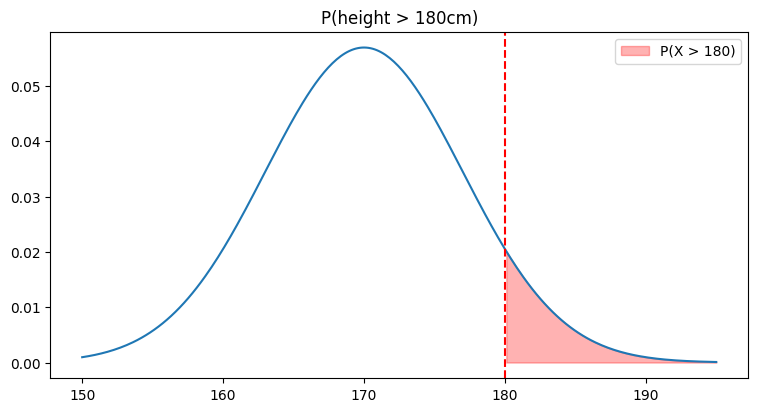

In [3]:
mu, sigma = 170, 7
prob_taller_than_180 = 1 - stats.norm.cdf(180, loc=mu, scale=sigma)
print(f"P(height > 180cm) = {prob_taller_than_180:.4f}  ({prob_taller_than_180*100:.2f}%)")

# Visualize it
x = np.linspace(150, 195, 300)
plt.plot(x, stats.norm.pdf(x, mu, sigma))
plt.fill_between(x[x>180], stats.norm.pdf(x[x>180], mu, sigma), alpha=0.3, color='red', label='P(X > 180)')
plt.axvline(180, color='red', ls='--')
plt.legend()
plt.title("P(height > 180cm)")
plt.show()


### 🎯 Your Turn

Using the same height distribution (Normal, mean=170, std=7):

1. What's the probability a random adult is **between 165cm and 175cm**?
2. What height corresponds to the **90th percentile**? (hint: use `stats.norm.ppf`, the inverse of `cdf`)


In [4]:
# TODO: compute P(165 < height < 175)
prob_between = None  # replace this

# TODO: compute the 90th percentile height
p90_height = None  # replace this

print(f"P(165 < height < 175) = {prob_between}")
print(f"90th percentile height = {p90_height}")


P(165 < height < 175) = None
90th percentile height = None


**Solution** (try it yourself first!)

In [5]:
prob_between = stats.norm.cdf(175, mu, sigma) - stats.norm.cdf(165, mu, sigma)
p90_height = stats.norm.ppf(0.90, loc=mu, scale=sigma)

print(f"P(165 < height < 175) = {prob_between:.4f}  ({prob_between*100:.2f}%)")
print(f"90th percentile height = {p90_height:.2f} cm")


P(165 < height < 175) = 0.5249  (52.49%)
90th percentile height = 178.97 cm


## 2. Population vs. Sample

Let's simulate a **known population** so we can compare true parameters (which we'd never
know in real life) against what a sample tells us.


TRUE population mean (mu):    24.039
TRUE population std dev (sigma): 13.836


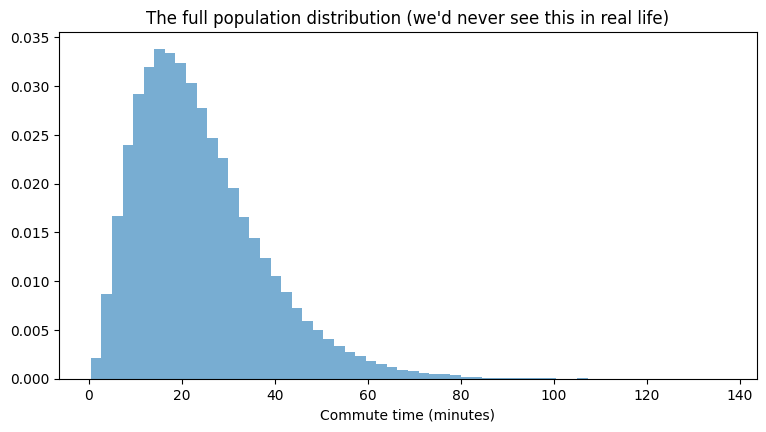

In [6]:
# Simulate a population of 100,000 "commute times" (minutes), right-skewed (like a real commute time distribution)
population = stats.gamma.rvs(a=3, scale=8, size=100_000, random_state=42)

true_mu = population.mean()
true_sigma = population.std()
print(f"TRUE population mean (mu):    {true_mu:.3f}")
print(f"TRUE population std dev (sigma): {true_sigma:.3f}")

plt.hist(population, bins=60, density=True, alpha=0.6)
plt.title("The full population distribution (we'd never see this in real life)")
plt.xlabel("Commute time (minutes)")
plt.show()


In [7]:
# Draw ONE random sample, like we would in real life
sample = np.random.choice(population, size=50, replace=False)

sample_mean = sample.mean()
sample_std = sample.std(ddof=1)  # ddof=1 -> sample std dev (n-1 denominator)

print(f"Sample mean (x-bar):       {sample_mean:.3f}   (true mu = {true_mu:.3f})")
print(f"Sample std dev (s):        {sample_std:.3f}   (true sigma = {true_sigma:.3f})")
print(f"Difference from true mean: {sample_mean - true_mu:+.3f}")


Sample mean (x-bar):       23.351   (true mu = 24.039)


Sample std dev (s):        15.632   (true sigma = 13.836)
Difference from true mean: -0.687


### 🎯 Your Turn

Draw **5 different samples** of size 50 from `population`, and print each sample mean. Notice
they're all a bit different from each other and from the true mean — this variability *is*
what a sampling distribution captures (Section 3).


In [8]:
# TODO: draw 5 samples of size 50 and print their means
for i in range(5):
    pass  # replace with your code


**Solution**

In [9]:
for i in range(5):
    s = np.random.choice(population, size=50, replace=False)
    print(f"Sample {i+1} mean: {s.mean():.3f}")


Sample 1 mean: 21.364
Sample 2 mean: 22.199
Sample 3 mean: 23.888
Sample 4 mean: 30.109
Sample 5 mean: 25.995


## 3. Sampling Distribution & the Central Limit Theorem

Let's actually **build** a sampling distribution by repeating the sampling process thousands
of times — something we can only do in a simulation, but it reveals what statistical theory
promises us for real, one-shot samples.

### The math: formal statement of the CLT

If $X_1, X_2, \dots, X_n$ are drawn independently from *any* population with mean $\mu$ and
finite variance $\sigma^2$, then as $n \to \infty$:

$$
\bar{X}_n \;\xrightarrow{d}\; \mathcal{N}\!\left(\mu, \frac{\sigma^2}{n}\right)
$$

Read this as: **the sampling distribution of the mean approaches Normal**, centered exactly
at the true population mean $\mu$, with variance shrinking as $\sigma^2/n$ — regardless of
what shape the original population had. This is *the* theoretical justification for every
z-test, t-test, and Normal-based confidence interval that follows, even when raw data (like
our right-skewed commute times) isn't Normal at all.


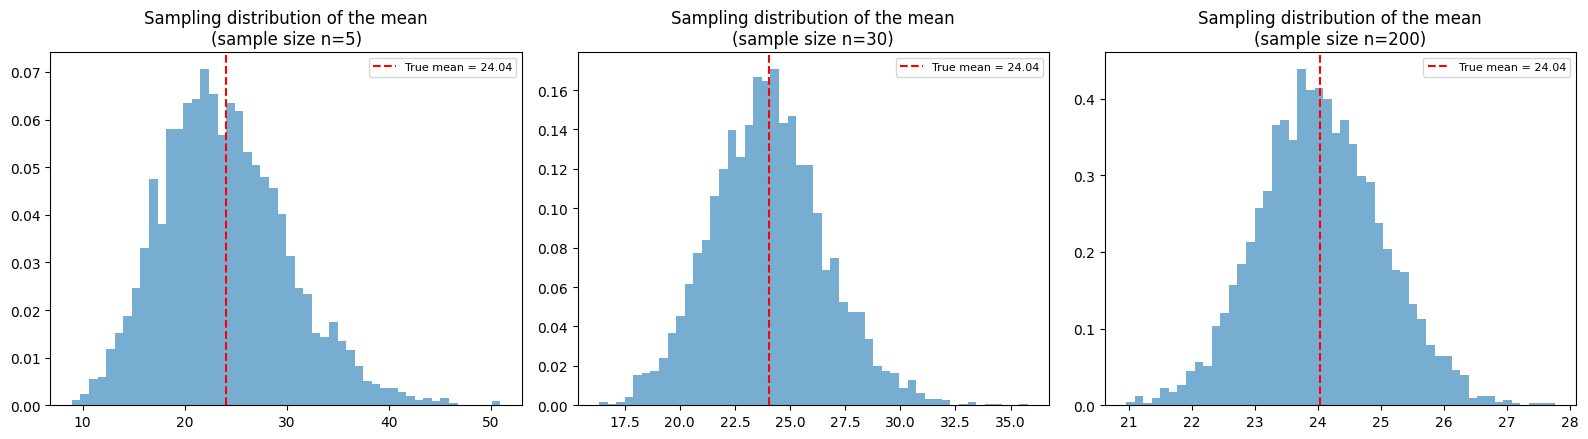

In [10]:
def simulate_sampling_distribution(population, sample_size, n_repeats=5000):
    means = np.zeros(n_repeats)
    for i in range(n_repeats):
        s = np.random.choice(population, size=sample_size, replace=False)
        means[i] = s.mean()
    return means

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

for ax, n in zip(axes, [5, 30, 200]):
    sampling_dist = simulate_sampling_distribution(population, sample_size=n, n_repeats=3000)
    ax.hist(sampling_dist, bins=50, density=True, alpha=0.6)
    ax.axvline(true_mu, color='red', ls='--', label=f'True mean = {true_mu:.2f}')
    ax.set_title(f"Sampling distribution of the mean\n(sample size n={n})")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()


**What to notice:** the original population (plotted in Section 2) is clearly
right-skewed — not Normal at all. But look what happens to the *sampling distribution of the
mean* as n grows: even at n=30 it already looks close to Normal, and by n=200 it's very
clearly Normal-shaped and much narrower. That narrowing and shape-convergence **is** the
Central Limit Theorem, made visible.


In [11]:
# Verify the Standard Error formula: SE = sigma / sqrt(n)
for n in [5, 30, 200]:
    sampling_dist = simulate_sampling_distribution(population, sample_size=n, n_repeats=3000)
    empirical_se = sampling_dist.std()
    theoretical_se = true_sigma / np.sqrt(n)
    print(f"n={n:3d}:  empirical SE = {empirical_se:.4f}   theoretical SE (sigma/sqrt(n)) = {theoretical_se:.4f}")


n=  5:  empirical SE = 6.0829   theoretical SE (sigma/sqrt(n)) = 6.1875


n= 30:  empirical SE = 2.5258   theoretical SE (sigma/sqrt(n)) = 2.5260


n=200:  empirical SE = 0.9749   theoretical SE (sigma/sqrt(n)) = 0.9783


### 🎯 Your Turn

The formula `SE = sigma / sqrt(n)` means quadrupling your sample size only **halves** your
standard error (since SE shrinks with the square root of n, not linearly). Confirm this:
compute the theoretical SE at n=25 and n=100, and check the ratio is exactly 2 (not 4).


In [12]:
# TODO: compute theoretical SE at n=25 and n=100, then their ratio
se_25 = None
se_100 = None
ratio = None

print(f"SE at n=25:  {se_25}")
print(f"SE at n=100: {se_100}")
print(f"Ratio (se_25 / se_100): {ratio}")


SE at n=25:  None
SE at n=100: None
Ratio (se_25 / se_100): None


**Solution**

In [13]:
se_25 = true_sigma / np.sqrt(25)
se_100 = true_sigma / np.sqrt(100)
ratio = se_25 / se_100

print(f"SE at n=25:  {se_25:.4f}")
print(f"SE at n=100: {se_100:.4f}")
print(f"Ratio (se_25 / se_100): {ratio:.2f}  <- quadrupling n exactly halves SE")


SE at n=25:  2.7671
SE at n=100: 1.3836
Ratio (se_25 / se_100): 2.00  <- quadrupling n exactly halves SE


## 4. Estimation — Unbiasedness in Action

Let's empirically verify that the **sample mean is an unbiased estimator**, and that using
the wrong denominator (n instead of n-1) makes the **sample variance biased**.

### The math: bias, and why n-1 fixes sample variance

An estimator $\hat{\theta}$ is **unbiased** if, on average across infinitely many samples, it
equals the true parameter:

$$
\text{Bias}(\hat{\theta}) = \mathbb{E}[\hat{\theta}] - \theta = 0
$$

The sample mean satisfies this exactly: $\mathbb{E}[\bar{X}] = \mu$.

The *naive* sample variance (dividing by $n$) does **not**:

$$
\mathbb{E}\left[\frac{1}{n}\sum_{i=1}^n (x_i - \bar{x})^2\right] = \frac{n-1}{n}\sigma^2 \quad \text{(systematically too small)}
$$

This happens because $\bar{x}$ is computed *from the same sample* it's being compared
against — it's the point that minimizes squared distances within that specific sample, so
those distances are a little smaller than distances to the true (unknown) $\mu$ would be.
Dividing by $n-1$ instead exactly corrects this:

$$
s^2 = \frac{1}{n-1}\sum_{i=1}^n (x_i - \bar{x})^2 \qquad \Rightarrow \qquad \mathbb{E}[s^2] = \sigma^2
$$


In [14]:
n_repeats = 5000
sample_size = 10

means = np.zeros(n_repeats)
var_n_minus_1 = np.zeros(n_repeats)   # correct (unbiased) sample variance
var_n = np.zeros(n_repeats)           # biased version (divides by n instead of n-1)

for i in range(n_repeats):
    s = np.random.choice(population, size=sample_size, replace=False)
    means[i] = s.mean()
    var_n_minus_1[i] = s.var(ddof=1)   # numpy default ddof=0 is the BIASED version; ddof=1 corrects it
    var_n[i] = s.var(ddof=0)

print(f"True population mean:                  {true_mu:.3f}")
print(f"Average of {n_repeats} sample means:          {means.mean():.3f}   <- should match true mean closely (unbiased)")
print()
print(f"True population variance:              {true_sigma**2:.3f}")
print(f"Average of sample variances (n-1, correct): {var_n_minus_1.mean():.3f}   <- should match true variance closely")
print(f"Average of sample variances (n, biased):    {var_n.mean():.3f}   <- systematically UNDERestimates true variance")


True population mean:                  24.039
Average of 5000 sample means:          24.118   <- should match true mean closely (unbiased)

True population variance:              191.423
Average of sample variances (n-1, correct): 191.696   <- should match true variance closely
Average of sample variances (n, biased):    172.527   <- systematically UNDERestimates true variance


**Why this happens:** a sample's own mean is, by construction, the point that minimizes
squared distances *within that sample* — so distances to the sample mean are always a little
smaller than distances to the true population mean would be. Dividing by n-1 instead of n
corrects for this small systematic underestimate. This is exactly why `pandas`/`numpy` sample
variance and standard deviation functions default to n-1 (Bessel's correction) — the same
detail from your covariance notebook.


### 🎯 Your Turn

Repeat the same simulation, but with `sample_size = 3` instead of 10. The bias in the `n`
(uncorrected) version should be noticeably **worse** with smaller samples. Confirm this.


In [15]:
# TODO: repeat the simulation above with sample_size = 3, print the same comparison


**Solution**

In [16]:
sample_size_small = 3
var_n_minus_1_small = np.zeros(n_repeats)
var_n_small = np.zeros(n_repeats)

for i in range(n_repeats):
    s = np.random.choice(population, size=sample_size_small, replace=False)
    var_n_minus_1_small[i] = s.var(ddof=1)
    var_n_small[i] = s.var(ddof=0)

print(f"True population variance:                   {true_sigma**2:.3f}")
print(f"Avg sample variance (n-1, correct), n=3:     {var_n_minus_1_small.mean():.3f}")
print(f"Avg sample variance (n, biased), n=3:        {var_n_small.mean():.3f}")
print(f"\n-> With only 3 observations per sample, the biased (n) version underestimates variance")
print(f"   by a much larger margin than it did with n=10 - the bias gets worse in small samples.")


True population variance:                   191.423
Avg sample variance (n-1, correct), n=3:     196.560
Avg sample variance (n, biased), n=3:        131.040

-> With only 3 observations per sample, the biased (n) version underestimates variance
   by a much larger margin than it did with n=10 - the bias gets worse in small samples.


## 5. Confidence Intervals

### The math

$$
\text{CI} = \bar{x} \; \pm \; t^{*}_{\,n-1} \cdot \frac{s}{\sqrt{n}}
$$

where $t^{*}_{\,n-1}$ is the critical value from the t-distribution with $n-1$ degrees of
freedom (use $z^{*}$ instead if $\sigma$ is known or $n$ is large). Notice the margin of
error shrinks as $\sqrt{n}$ grows and widens as $s$ grows — exactly the standard error
relationship from Section 3.

### Worked example: build a 95% CI by hand, then check it with `scipy`


In [17]:
sample = np.random.choice(population, size=50, replace=False)
x_bar = sample.mean()
s = sample.std(ddof=1)
n = len(sample)

# --- Manual calculation using the t-distribution (population sigma unknown) ---
confidence = 0.95
alpha = 1 - confidence
df = n - 1
t_critical = stats.t.ppf(1 - alpha/2, df=df)
margin_of_error = t_critical * (s / np.sqrt(n))

ci_lower = x_bar - margin_of_error
ci_upper = x_bar + margin_of_error

print(f"Sample mean: {x_bar:.3f}")
print(f"t critical value (df={df}): {t_critical:.3f}")
print(f"Margin of error: {margin_of_error:.3f}")
print(f"95% CI (manual): ({ci_lower:.3f}, {ci_upper:.3f})")

# --- Check against scipy's built-in function ---
ci_scipy = stats.t.interval(confidence, df=df, loc=x_bar, scale=s/np.sqrt(n))
print(f"95% CI (scipy):  ({ci_scipy[0]:.3f}, {ci_scipy[1]:.3f})")
print(f"\nTrue population mean ({true_mu:.3f}) inside this CI? {ci_lower <= true_mu <= ci_upper}")


Sample mean: 27.002
t critical value (df=49): 2.010
Margin of error: 4.746
95% CI (manual): (22.256, 31.748)
95% CI (scipy):  (22.256, 31.748)

True population mean (24.039) inside this CI? True


### The big demo: does a 95% CI *really* capture the true mean 95% of the time?

This is the experiment that makes the correct interpretation of confidence intervals click.
We'll build 100 different 95% CIs from 100 different samples, and count how many actually
contain the true population mean.


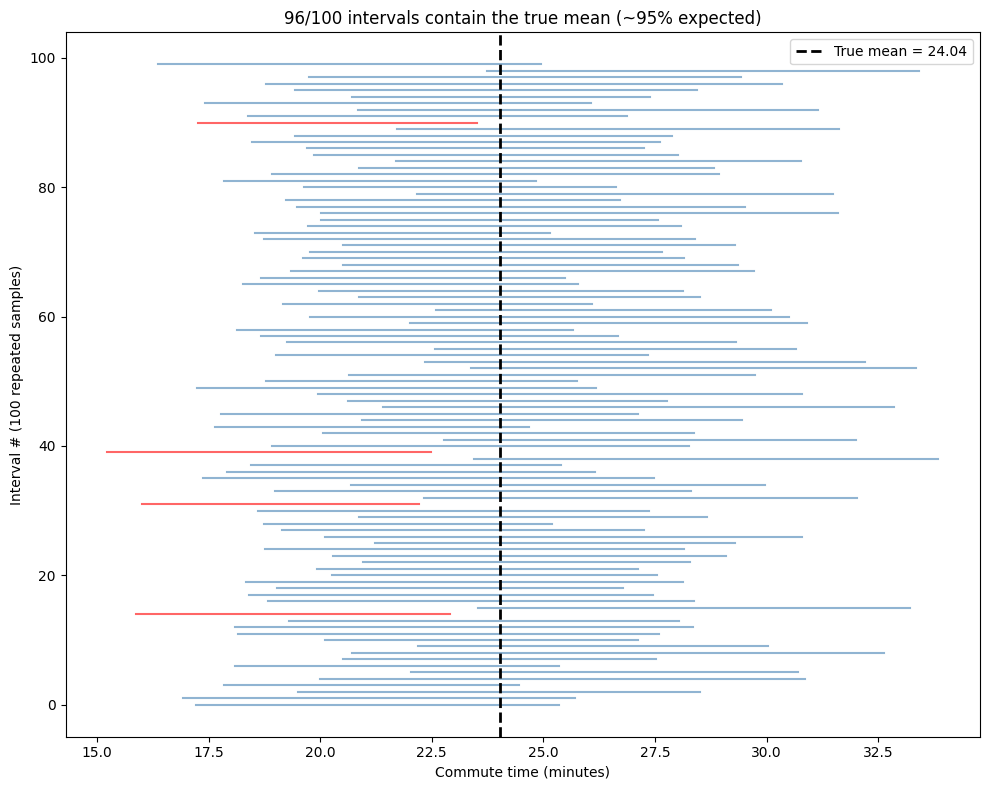

96 out of 100 intervals (96%) contained the true mean.
This should be close to 95 - confirming the correct interpretation:
'95% of intervals BUILT THIS WAY will contain the true mean', not
'there's a 95% chance the true mean is in any ONE specific interval'.


In [18]:
n_intervals = 100
sample_size = 40
contains_true_mean = 0

fig, ax = plt.subplots(figsize=(10, 8))

for i in range(n_intervals):
    s = np.random.choice(population, size=sample_size, replace=False)
    x_bar_i = s.mean()
    se_i = s.std(ddof=1) / np.sqrt(sample_size)
    ci_low, ci_high = stats.t.interval(0.95, df=sample_size-1, loc=x_bar_i, scale=se_i)

    contains = ci_low <= true_mu <= ci_high
    contains_true_mean += contains
    color = 'steelblue' if contains else 'red'
    ax.plot([ci_low, ci_high], [i, i], color=color, alpha=0.6)

ax.axvline(true_mu, color='black', ls='--', lw=2, label=f'True mean = {true_mu:.2f}')
ax.set_xlabel("Commute time (minutes)")
ax.set_ylabel("Interval # (100 repeated samples)")
ax.set_title(f"{contains_true_mean}/100 intervals contain the true mean (~95% expected)")
ax.legend()
plt.tight_layout()
plt.show()

print(f"{contains_true_mean} out of {n_intervals} intervals ({contains_true_mean}%) contained the true mean.")
print("This should be close to 95 - confirming the correct interpretation:")
print("'95% of intervals BUILT THIS WAY will contain the true mean', not")
print("'there's a 95% chance the true mean is in any ONE specific interval'.")


### 🎯 Your Turn

Re-run the 100-interval simulation above, but using **80% confidence** instead of 95%. Do you
expect wider or narrower intervals? Do you expect more or fewer red (missing) intervals?
Check your intuition against the result.


In [19]:
# TODO: repeat the 100-interval simulation with confidence=0.80 instead of 0.95


**Solution**

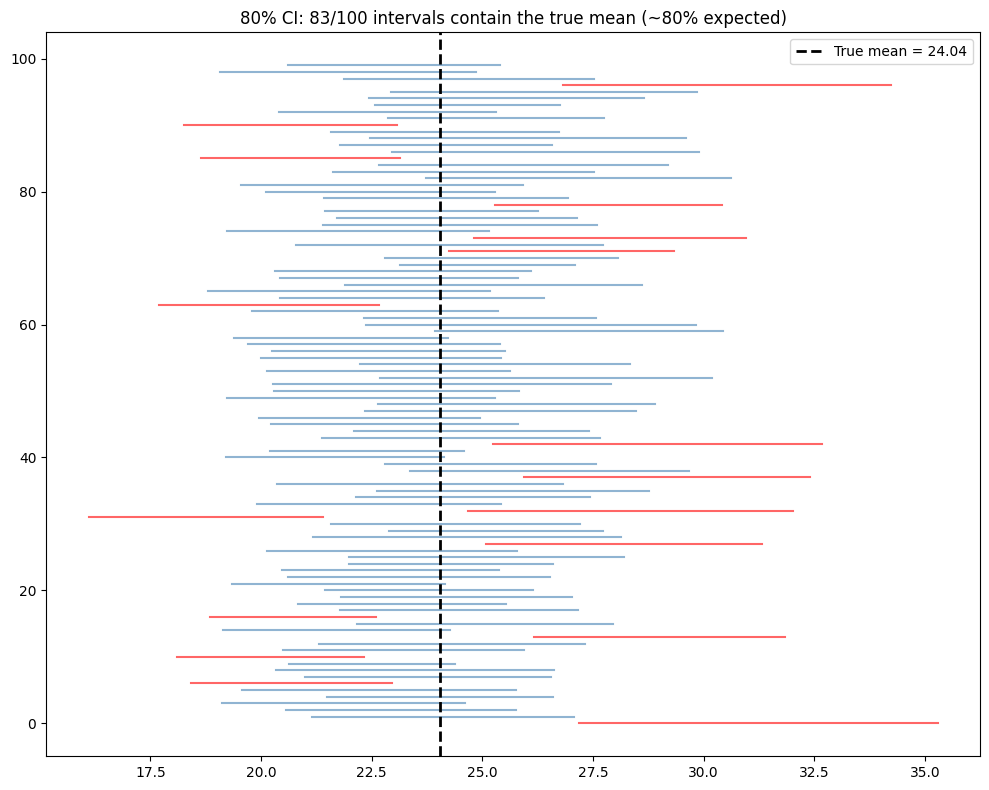

83/100 intervals contained the true mean.
Lower confidence -> narrower intervals -> MORE of them miss the true mean.
This is the width/confidence tradeoff from Section 5 of the study notes.


In [20]:
n_intervals = 100
sample_size = 40
contains_true_mean_80 = 0

fig, ax = plt.subplots(figsize=(10, 8))

for i in range(n_intervals):
    s = np.random.choice(population, size=sample_size, replace=False)
    x_bar_i = s.mean()
    se_i = s.std(ddof=1) / np.sqrt(sample_size)
    ci_low, ci_high = stats.t.interval(0.80, df=sample_size-1, loc=x_bar_i, scale=se_i)

    contains = ci_low <= true_mu <= ci_high
    contains_true_mean_80 += contains
    color = 'steelblue' if contains else 'red'
    ax.plot([ci_low, ci_high], [i, i], color=color, alpha=0.6)

ax.axvline(true_mu, color='black', ls='--', lw=2, label=f'True mean = {true_mu:.2f}')
ax.set_title(f"80% CI: {contains_true_mean_80}/100 intervals contain the true mean (~80% expected)")
ax.legend()
plt.tight_layout()
plt.show()

print(f"{contains_true_mean_80}/100 intervals contained the true mean.")
print("Lower confidence -> narrower intervals -> MORE of them miss the true mean.")
print("This is the width/confidence tradeoff from Section 5 of the study notes.")


### 5.1 Bootstrap Confidence Intervals (a modern alternative)

Everything above assumes a Normal/t sampling distribution. When that assumption feels shaky
(small sample, weird shape, or a statistic like the median that doesn't have a clean formula),
**bootstrap resampling** builds a CI empirically instead — resample *with replacement* from
your one real sample, recompute the statistic each time, and take percentiles of the results.


t-based 95% CI:        (21.791, 30.682)
Bootstrap 95% CI:      (22.149, 30.739)
-> Similar for the mean (both rely on averaging), but bootstrap also works for
   statistics like the median where there's no simple textbook formula:



Bootstrap 95% CI for the MEDIAN: (20.182, 28.292)


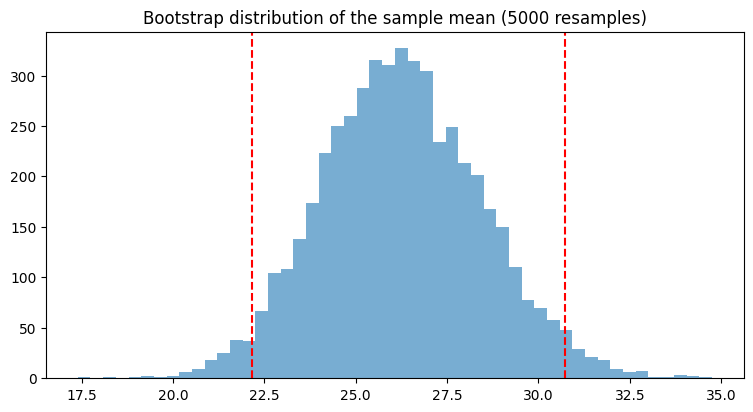

In [21]:
def bootstrap_ci(data, stat_func=np.mean, n_boot=5000, ci=0.95):
    boot_stats = np.zeros(n_boot)
    n = len(data)
    for i in range(n_boot):
        resample = np.random.choice(data, size=n, replace=True)
        boot_stats[i] = stat_func(resample)
    lower = np.percentile(boot_stats, (1-ci)/2 * 100)
    upper = np.percentile(boot_stats, (1 - (1-ci)/2) * 100)
    return lower, upper, boot_stats

one_sample = np.random.choice(population, size=50, replace=False)

boot_lower, boot_upper, boot_dist = bootstrap_ci(one_sample, stat_func=np.mean)
t_lower, t_upper = stats.t.interval(0.95, df=49, loc=one_sample.mean(), scale=one_sample.std(ddof=1)/np.sqrt(50))

print(f"t-based 95% CI:        ({t_lower:.3f}, {t_upper:.3f})")
print(f"Bootstrap 95% CI:      ({boot_lower:.3f}, {boot_upper:.3f})")
print("-> Similar for the mean (both rely on averaging), but bootstrap also works for")
print("   statistics like the median where there's no simple textbook formula:")

boot_lower_med, boot_upper_med, boot_dist_med = bootstrap_ci(one_sample, stat_func=np.median)
print(f"\nBootstrap 95% CI for the MEDIAN: ({boot_lower_med:.3f}, {boot_upper_med:.3f})")

plt.hist(boot_dist, bins=50, alpha=0.6)
plt.axvline(boot_lower, color='red', ls='--')
plt.axvline(boot_upper, color='red', ls='--')
plt.title("Bootstrap distribution of the sample mean (5000 resamples)")
plt.show()


### 🎯 Your Turn

Build a bootstrap 95% CI for the **standard deviation** of `one_sample` (another statistic
with no simple textbook CI formula). Reuse the `bootstrap_ci` function.


In [22]:
# TODO: bootstrap CI for the std dev of one_sample


**Solution**

In [23]:
boot_lower_std, boot_upper_std, _ = bootstrap_ci(one_sample, stat_func=lambda x: x.std(ddof=1))
print(f"Bootstrap 95% CI for std dev: ({boot_lower_std:.3f}, {boot_upper_std:.3f})")
print(f"(Sample std dev itself: {one_sample.std(ddof=1):.3f})")


Bootstrap 95% CI for std dev: (11.991, 18.730)
(Sample std dev itself: 15.641)


## 6. Hypothesis Testing — Real Data (Auto MPG)

Let's switch to real data and practice the full workflow: state hypotheses, run the test,
interpret the p-value.

### The math: the t-statistic

Every t-test in this section computes some version of the same ratio — how far apart are the
things being compared, relative to how much noise we'd expect just from sampling variability:

$$
t = \frac{\text{observed difference}}{\text{standard error of that difference}}
$$

For a **one-sample** test against a hypothesized value $\mu_0$:

$$
t = \frac{\bar{x} - \mu_0}{s / \sqrt{n}}, \qquad \text{df} = n - 1
$$

For a **two-sample** test (Welch's version, which doesn't assume equal variances):

$$
t = \frac{\bar{x}_1 - \bar{x}_2}{\sqrt{\dfrac{s_1^2}{n_1} + \dfrac{s_2^2}{n_2}}}
$$

The resulting $t$ value is compared against a t-distribution to get the p-value — a large
$|t|$ means the observed difference is large relative to the noise, producing a small p-value.


In [24]:
url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/mpg.csv"
mpg_df = pd.read_csv(url).dropna(subset=['horsepower', 'mpg'])
mpg_df.head()


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino


### 6.1 One-sample t-test

**Question:** the advertised "average" mpg across this era of cars is often quoted as 20 mpg.
Does our data support that, or is the true average significantly different?

- H0: population mean mpg = 20
- H1: population mean mpg ≠ 20 (two-tailed)


In [25]:
t_stat, p_value = stats.ttest_1samp(mpg_df['mpg'], popmean=20)

print(f"Sample mean mpg: {mpg_df['mpg'].mean():.3f}")
print(f"t-statistic: {t_stat:.3f}")
print(f"p-value: {p_value:.6f}")

alpha = 0.05
if p_value < alpha:
    print(f"\np < {alpha}: reject H0. The true average mpg is significantly different from 20.")
else:
    print(f"\np >= {alpha}: fail to reject H0. Not enough evidence that average mpg differs from 20.")


Sample mean mpg: 23.446
t-statistic: 8.741
p-value: 0.000000

p < 0.05: reject H0. The true average mpg is significantly different from 20.


### 6.2 Two-sample t-test

**Question:** do Japanese cars and American cars have significantly different average mpg?

- H0: mean mpg (Japan) = mean mpg (USA)
- H1: mean mpg (Japan) ≠ mean mpg (USA)


Japan: n=79, mean=30.45, std=6.09
USA:   n=245, mean=20.03, std=6.44

t-statistic: 13.034
p-value: 7.51e-26

p < 0.05: reject H0. Japanese and American cars have significantly different average mpg.


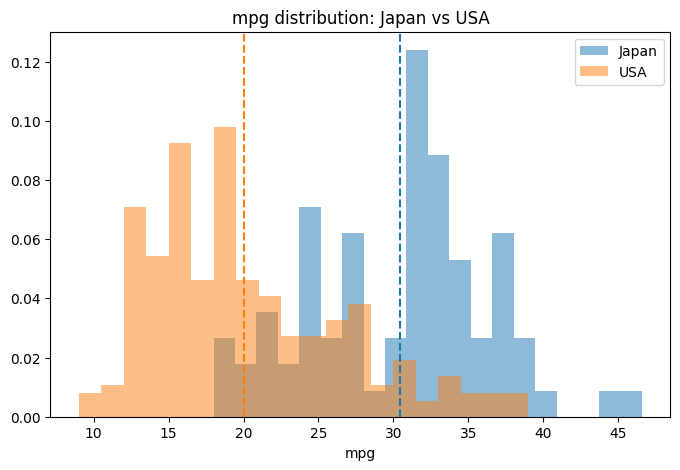

In [26]:
url_full = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/mpg.csv"
mpg_full = pd.read_csv(url_full).dropna(subset=['horsepower', 'mpg', 'origin'])

japan_mpg = mpg_full[mpg_full['origin'] == 'japan']['mpg']
usa_mpg = mpg_full[mpg_full['origin'] == 'usa']['mpg']

print(f"Japan: n={len(japan_mpg)}, mean={japan_mpg.mean():.2f}, std={japan_mpg.std():.2f}")
print(f"USA:   n={len(usa_mpg)}, mean={usa_mpg.mean():.2f}, std={usa_mpg.std():.2f}")

t_stat2, p_value2 = stats.ttest_ind(japan_mpg, usa_mpg, equal_var=False)  # Welch's t-test - doesn't assume equal variances
print(f"\nt-statistic: {t_stat2:.3f}")
print(f"p-value: {p_value2:.2e}")

if p_value2 < 0.05:
    print("\np < 0.05: reject H0. Japanese and American cars have significantly different average mpg.")
else:
    print("\np >= 0.05: fail to reject H0.")

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(japan_mpg, bins=20, alpha=0.5, label='Japan', density=True)
ax.hist(usa_mpg, bins=20, alpha=0.5, label='USA', density=True)
ax.axvline(japan_mpg.mean(), color='C0', ls='--')
ax.axvline(usa_mpg.mean(), color='C1', ls='--')
ax.legend()
ax.set_xlabel('mpg')
ax.set_title('mpg distribution: Japan vs USA')
plt.show()


**Note on effect size:** a significant p-value tells us the difference is unlikely to be
due to chance, but doesn't tell us *how big* the difference is. Here the actual mean gap is
substantial (several mpg) — worth checking any time you get a significant result, per the
"statistical vs. practical significance" point in the study notes.


### 6.3 Chi-square test — categorical relationship

**Question:** is engine cylinder count independent of country of origin?

- H0: cylinder count and origin are independent
- H1: cylinder count and origin are NOT independent


In [27]:
contingency = pd.crosstab(mpg_full['cylinders'], mpg_full['origin'])
print(contingency)

chi2, p_value3, dof, expected = stats.chi2_contingency(contingency)
print(f"\nChi-square statistic: {chi2:.2f}")
print(f"p-value: {p_value3:.6f}")
print(f"Degrees of freedom: {dof}")

if p_value3 < 0.05:
    print("\np < 0.05: reject H0. Cylinder count and origin are NOT independent.")


origin     europe  japan  usa
cylinders                    
3               0      4    0
4              61     69   69
5               3      0    0
6               4      6   73
8               0      0  103

Chi-square statistic: 180.72
p-value: 0.000000
Degrees of freedom: 8

p < 0.05: reject H0. Cylinder count and origin are NOT independent.


### 6.4 ANOVA — comparing 3+ groups at once

**Question:** does average mpg differ across all three origins simultaneously (not just a
pairwise comparison)?

- H0: mean mpg is equal across Japan, USA, and Europe
- H1: at least one origin has a different mean mpg


In [28]:
europe_mpg = mpg_full[mpg_full['origin'] == 'europe']['mpg']

f_stat, p_value4 = stats.f_oneway(japan_mpg, usa_mpg, europe_mpg)
print(f"F-statistic: {f_stat:.3f}")
print(f"p-value: {p_value4:.2e}")

if p_value4 < 0.05:
    print("\np < 0.05: reject H0. At least one origin group has a significantly different mean mpg.")
    print("(Note: ANOVA tells us THAT a difference exists, not WHICH pair(s) differ -")
    print(" for that you'd follow up with pairwise t-tests, adjusted for multiple testing.)")


F-statistic: 96.602
p-value: 8.67e-35

p < 0.05: reject H0. At least one origin group has a significantly different mean mpg.
(Note: ANOVA tells us THAT a difference exists, not WHICH pair(s) differ -
 for that you'd follow up with pairwise t-tests, adjusted for multiple testing.)


### 🎯 Your Turn

Run a two-sample t-test comparing `horsepower` between Japan and USA (same structure as
Section 6.2, different column and likely a very different result). State your H0/H1 first,
then interpret the p-value in a sentence.


In [29]:
# TODO: state H0 and H1 in a comment, then run the two-sample t-test on 'horsepower'


**Solution**

In [30]:
# H0: mean horsepower (Japan) = mean horsepower (USA)
# H1: mean horsepower (Japan) != mean horsepower (USA)

japan_hp = mpg_full[mpg_full['origin'] == 'japan']['horsepower']
usa_hp = mpg_full[mpg_full['origin'] == 'usa']['horsepower']

t_stat_hp, p_value_hp = stats.ttest_ind(japan_hp, usa_hp, equal_var=False)

print(f"Japan mean horsepower: {japan_hp.mean():.2f}")
print(f"USA mean horsepower:   {usa_hp.mean():.2f}")
print(f"t-statistic: {t_stat_hp:.3f}")
print(f"p-value: {p_value_hp:.2e}")

if p_value_hp < 0.05:
    print("\nInterpretation: p < 0.05, so we reject H0 - there IS a statistically significant")
    print("difference in average horsepower between Japanese and American cars in this data,")
    print("with American cars showing substantially higher average horsepower.")


Japan mean horsepower: 79.84
USA mean horsepower:   119.05
t-statistic: -12.092
p-value: 1.51e-27

Interpretation: p < 0.05, so we reject H0 - there IS a statistically significant
difference in average horsepower between Japanese and American cars in this data,
with American cars showing substantially higher average horsepower.


## 7. Type I/II Error, Effect Size, and Power

### 7.1 Visualizing Type I and Type II Error

These two error types are easiest to understand as overlapping distributions: the sampling
distribution under H0 (no effect) vs. under H1 (a real effect of some size).


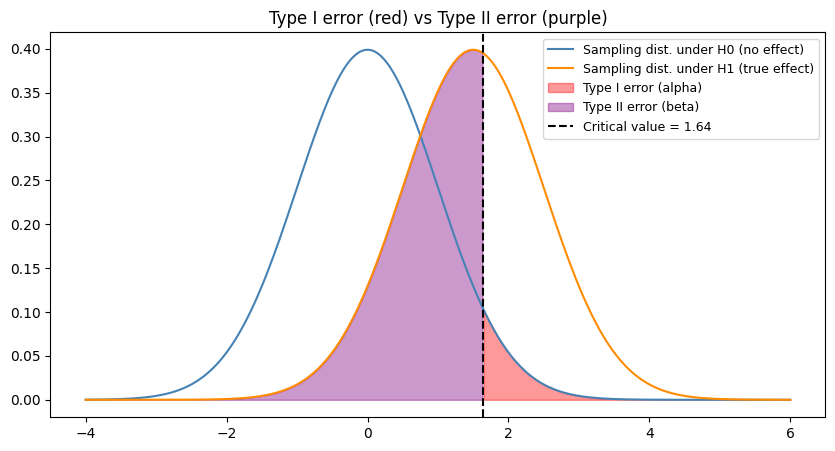

alpha (Type I error rate):  0.050   <- we CHOOSE this
beta (Type II error rate):  0.558   <- depends on effect size, n, and alpha
Power (1 - beta):           0.442


In [31]:
mu0, mu1 = 0, 1.5   # H0: true mean = 0.   H1: true mean = 1.5 (a real effect exists)
se = 1.0             # standard error of the sampling distribution
alpha = 0.05

critical_value = stats.norm.ppf(1 - alpha, loc=mu0, scale=se)

x = np.linspace(-4, 6, 500)
h0_dist = stats.norm.pdf(x, mu0, se)
h1_dist = stats.norm.pdf(x, mu1, se)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(x, h0_dist, label='Sampling dist. under H0 (no effect)', color='steelblue')
ax.plot(x, h1_dist, label='Sampling dist. under H1 (true effect)', color='darkorange')

# Type I error: area under H0 curve beyond the critical value
x_typeI = x[x >= critical_value]
ax.fill_between(x_typeI, stats.norm.pdf(x_typeI, mu0, se), alpha=0.4, color='red', label='Type I error (alpha)')

# Type II error: area under H1 curve BELOW the critical value
x_typeII = x[x <= critical_value]
ax.fill_between(x_typeII, stats.norm.pdf(x_typeII, mu1, se), alpha=0.4, color='purple', label='Type II error (beta)')

ax.axvline(critical_value, color='black', ls='--', label=f'Critical value = {critical_value:.2f}')
ax.legend(fontsize=9)
ax.set_title("Type I error (red) vs Type II error (purple)")
plt.show()

beta = stats.norm.cdf(critical_value, mu1, se)
power = 1 - beta
print(f"alpha (Type I error rate):  {alpha:.3f}   <- we CHOOSE this")
print(f"beta (Type II error rate):  {beta:.3f}   <- depends on effect size, n, and alpha")
print(f"Power (1 - beta):           {power:.3f}")


**What to notice:** the two curves overlap. Moving the critical value left (smaller
alpha threshold) shrinks Type I error but *grows* Type II error, and vice versa — there's an
inherent tradeoff, not a free lunch. The only way to shrink **both** simultaneously is to
reduce the overlap itself, by increasing sample size (which narrows both curves) or by the
true effect being larger to begin with.


### 7.2 Effect Size (Cohen's d)

A p-value tells you *whether* an effect is statistically detectable; effect size tells you
*how big* it is, independent of sample size.

$$
d = \frac{\bar{x}_1 - \bar{x}_2}{s_{\text{pooled}}}, \qquad
s_{\text{pooled}} = \sqrt{\frac{(n_1-1)s_1^2 + (n_2-1)s_2^2}{n_1+n_2-2}}
$$

Rule of thumb: |d| ≈ 0.2 small, 0.5 medium, 0.8 large.


In [32]:
def cohens_d(x1, x2):
    n1, n2 = len(x1), len(x2)
    pooled_std = np.sqrt(((n1-1)*x1.var(ddof=1) + (n2-1)*x2.var(ddof=1)) / (n1+n2-2))
    return (x1.mean() - x2.mean()) / pooled_std

d_mpg = cohens_d(japan_mpg, usa_mpg)
d_hp = cohens_d(japan_hp, usa_hp)

print(f"Cohen's d for mpg (Japan vs USA):        {d_mpg:.3f}")
print(f"Cohen's d for horsepower (Japan vs USA): {d_hp:.3f}")
print("\nBoth comparisons were statistically significant (Section 6), but effect size tells us")
print("how large those differences actually are in practical terms - useful because with a")
print("large enough sample, even a tiny, unimportant difference can become 'significant'.")


Cohen's d for mpg (Japan vs USA):        1.639
Cohen's d for horsepower (Japan vs USA): -1.095

Both comparisons were statistically significant (Section 6), but effect size tells us
how large those differences actually are in practical terms - useful because with a
large enough sample, even a tiny, unimportant difference can become 'significant'.


### 7.3 Statistical Power & Sample Size

**Power** = P(correctly detecting a real effect) = 1 − β. Low power means you might miss a
real effect entirely (a Type II error) — this is why power analysis matters *before*
collecting data, to figure out how large a sample you actually need.


In [33]:
from scipy.stats import norm

def required_sample_size(effect_size, alpha=0.05, power=0.80):
    z_alpha = norm.ppf(1 - alpha/2)   # two-tailed
    z_beta = norm.ppf(power)
    n = 2 * ((z_alpha + z_beta) / effect_size) ** 2
    return int(np.ceil(n))

for es in [0.2, 0.5, 0.8]:
    n_needed = required_sample_size(effect_size=es)
    label = {0.2: 'small', 0.5: 'medium', 0.8: 'large'}[es]
    print(f"Effect size {es} ({label:>6}): need ~{n_needed} per group for 80% power at alpha=0.05")

print("\n-> Detecting SMALL effects reliably requires dramatically larger samples than")
print("   detecting large ones - a key practical planning consideration.")


Effect size 0.2 ( small): need ~393 per group for 80% power at alpha=0.05
Effect size 0.5 (medium): need ~63 per group for 80% power at alpha=0.05
Effect size 0.8 ( large): need ~25 per group for 80% power at alpha=0.05

-> Detecting SMALL effects reliably requires dramatically larger samples than
   detecting large ones - a key practical planning consideration.


### 🎯 Your Turn

Compute Cohen's d for `weight` between Japan and USA. Is it small, medium, or large by the
rule of thumb above?


In [34]:
# TODO: compute Cohen's d for weight, Japan vs USA


**Solution**

In [35]:
japan_weight = mpg_full[mpg_full['origin'] == 'japan']['weight']
usa_weight = mpg_full[mpg_full['origin'] == 'usa']['weight']

d_weight = cohens_d(japan_weight, usa_weight)
print(f"Cohen's d for weight (Japan vs USA): {d_weight:.3f}")
print("-> This is a LARGE effect by the rule of thumb (|d| > 0.8) - American cars in this")
print("   era were substantially and meaningfully heavier, not just statistically different.")


Cohen's d for weight (Japan vs USA): -1.621
-> This is a LARGE effect by the rule of thumb (|d| > 0.8) - American cars in this
   era were substantially and meaningfully heavier, not just statistically different.


## 8. Beyond the t-test: Non-Parametric & Resampling-Based Tests

### 8.1 Mann-Whitney U test (non-parametric alternative to the two-sample t-test)

The t-test assumes roughly Normal data (or relies on the CLT for large n). When that's shaky
— small samples, heavy skew, obvious outliers — the **Mann-Whitney U test** compares group
*ranks* instead of raw values, making it far more robust to outliers and non-Normality.


In [36]:
u_stat, p_value_mw = stats.mannwhitneyu(japan_mpg, usa_mpg, alternative='two-sided')

print(f"Mann-Whitney U statistic: {u_stat:.1f}")
print(f"p-value: {p_value_mw:.2e}")
print(f"(Compare to the t-test p-value from Section 6.2: {p_value2:.2e})")
print("\n-> Both tests agree here since mpg isn't wildly non-Normal, but Mann-Whitney would")
print("   be the safer choice with a smaller or more skewed dataset.")


Mann-Whitney U statistic: 16898.5
p-value: 1.92e-23
(Compare to the t-test p-value from Section 6.2: 7.51e-26)

-> Both tests agree here since mpg isn't wildly non-Normal, but Mann-Whitney would
   be the safer choice with a smaller or more skewed dataset.


### 8.2 Permutation Test (assumption-free)

The most intuitive test of all: if there's truly no difference between groups, the group
labels ('japan'/'usa') are meaningless — shuffling them randomly should produce differences
just as extreme as the real one about as often as not. We simulate that directly.


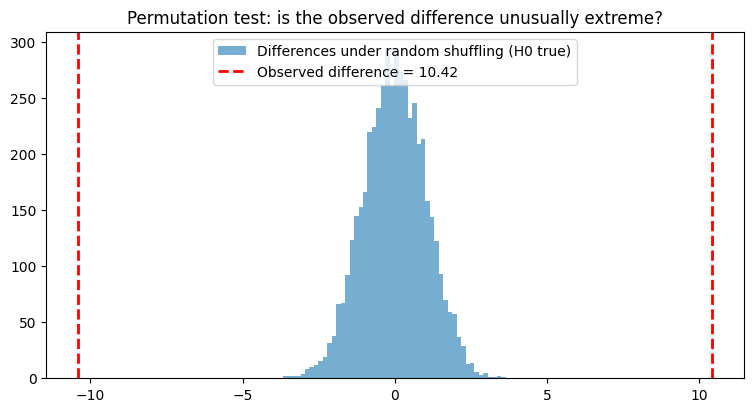

Observed difference (Japan - USA): 10.417
Permutation test p-value: 0.0000
(Compare to t-test p-value: 7.51e-26 - both lead to the same conclusion here)


In [37]:
observed_diff = japan_mpg.mean() - usa_mpg.mean()

combined = np.concatenate([japan_mpg.values, usa_mpg.values])
n_japan = len(japan_mpg)
n_perm = 5000
perm_diffs = np.zeros(n_perm)

for i in range(n_perm):
    shuffled = np.random.permutation(combined)
    perm_diffs[i] = shuffled[:n_japan].mean() - shuffled[n_japan:].mean()

p_value_perm = np.mean(np.abs(perm_diffs) >= np.abs(observed_diff))

plt.hist(perm_diffs, bins=50, alpha=0.6, label='Differences under random shuffling (H0 true)')
plt.axvline(observed_diff, color='red', ls='--', lw=2, label=f'Observed difference = {observed_diff:.2f}')
plt.axvline(-observed_diff, color='red', ls='--', lw=2)
plt.legend()
plt.title("Permutation test: is the observed difference unusually extreme?")
plt.show()

print(f"Observed difference (Japan - USA): {observed_diff:.3f}")
print(f"Permutation test p-value: {p_value_perm:.4f}")
print(f"(Compare to t-test p-value: {p_value2:.2e} - both lead to the same conclusion here)")


**Why this matters:** the permutation test makes **zero distributional assumptions** —
no Normality, no CLT reliance. It directly simulates "what would happen under H0" from the
data itself, which is why it's a good sanity check against parametric tests, especially with
small or unusual samples.


### 8.3 Multiple Testing Correction (Bonferroni)

Running many hypothesis tests inflates the chance that *something* looks significant purely
by chance. Let's test mpg differences across several origin *pairs and* several other numeric
columns at once, then correct for it.


In [38]:
from itertools import combinations

columns_to_test = ['mpg', 'horsepower', 'weight', 'acceleration', 'displacement']
origins = ['japan', 'usa', 'europe']
pairs = list(combinations(origins, 2))

results = []
for col in columns_to_test:
    for o1, o2 in pairs:
        g1 = mpg_full[mpg_full['origin'] == o1][col]
        g2 = mpg_full[mpg_full['origin'] == o2][col]
        _, p = stats.ttest_ind(g1, g2, equal_var=False)
        results.append({'column': col, 'comparison': f'{o1} vs {o2}', 'p_value': p})

results_df = pd.DataFrame(results)
n_tests = len(results_df)
alpha = 0.05
bonferroni_alpha = alpha / n_tests

results_df['significant_uncorrected'] = results_df['p_value'] < alpha
results_df['significant_bonferroni'] = results_df['p_value'] < bonferroni_alpha

print(f"Total tests run: {n_tests}")
print(f"Original alpha: {alpha}")
print(f"Bonferroni-corrected alpha: {bonferroni_alpha:.5f}  (= {alpha} / {n_tests})")
print()
print(results_df.sort_values('p_value').to_string(index=False))
print(f"\nSignificant at original alpha:    {results_df['significant_uncorrected'].sum()} / {n_tests}")
print(f"Significant after Bonferroni:     {results_df['significant_bonferroni'].sum()} / {n_tests}")


Total tests run: 15
Original alpha: 0.05
Bonferroni-corrected alpha: 0.00333  (= 0.05 / 15)

      column      comparison      p_value  significant_uncorrected  significant_bonferroni
displacement    japan vs usa 2.270507e-62                     True                    True
displacement   usa vs europe 7.771143e-58                     True                    True
      weight    japan vs usa 8.394203e-52                     True                    True
  horsepower    japan vs usa 1.514632e-27                     True                    True
         mpg    japan vs usa 7.513384e-26                     True                    True
      weight   usa vs europe 1.583163e-24                     True                    True
  horsepower   usa vs europe 2.106571e-22                     True                    True
         mpg   usa vs europe 1.929839e-13                     True                    True
acceleration   usa vs europe 3.146668e-05                     True                    Tr

**Reading this:** with `n_tests` comparisons running simultaneously, some might have
crossed the p < 0.05 threshold by chance alone even if there were no real effect. Bonferroni
divides alpha by the number of tests, making the bar much higher to clear — it's
conservative (trades some power for protection against false positives), which is the right
tradeoff when false discoveries are costly.


## 9. Final Mini-Project

Put everything together on a fresh question, end to end.

**Task:** Investigate whether `weight` differs significantly between cars made before 1975
and cars made in 1975 or later (`model_year` is coded as 2-digit years: 70 = 1970, etc.).

Work through the full pipeline yourself:
1. Split the data into the two groups
2. Compute descriptive stats for each group (mean, std, n)
3. State H0 and H1
4. Run the appropriate test
5. Build a 95% CI for each group's mean weight
6. Write a 2-3 sentence conclusion, including both statistical AND practical significance


In [39]:
# TODO: your full mini-project code here


**Solution**

Descriptive statistics:
Before 1975: n=150, mean=3212.6, std=977.2
1975+:       n=242, mean=2831.9, std=724.2

t-statistic: 4.120
p-value: 5.15e-05

95% CI, before 1975: (3054.9, 3370.2)
95% CI, 1975+:       (2740.2, 2923.6)


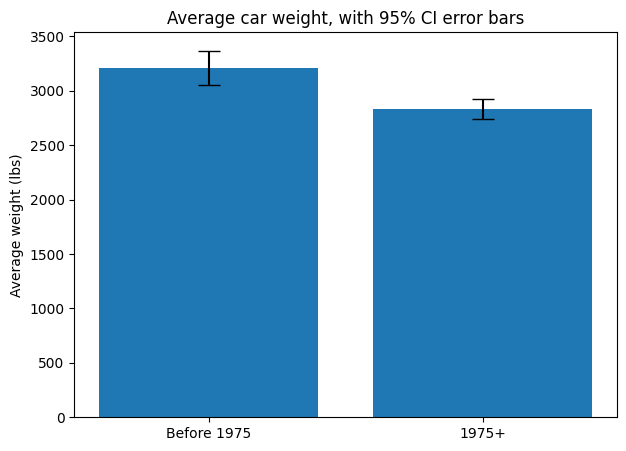


Conclusion: with p < 0.05, we reject H0 - there is a statistically significant
difference in average car weight before vs. after 1975. The two 95% confidence
intervals don't overlap, reinforcing the same conclusion (CI/test duality). The gap
is also large in absolute terms (several hundred pounds), so this is both statistically
AND practically significant - likely reflecting the shift toward smaller, more fuel-
efficient cars following the 1970s oil crisis.


In [40]:
before_1975 = mpg_full[mpg_full['model_year'] < 75]['weight']
from_1975 = mpg_full[mpg_full['model_year'] >= 75]['weight']

print("Descriptive statistics:")
print(f"Before 1975: n={len(before_1975)}, mean={before_1975.mean():.1f}, std={before_1975.std():.1f}")
print(f"1975+:       n={len(from_1975)}, mean={from_1975.mean():.1f}, std={from_1975.std():.1f}")

# H0: mean weight (before 1975) = mean weight (1975+)
# H1: mean weight (before 1975) != mean weight (1975+)

t_stat_w, p_value_w = stats.ttest_ind(before_1975, from_1975, equal_var=False)
print(f"\nt-statistic: {t_stat_w:.3f}")
print(f"p-value: {p_value_w:.2e}")

ci_before = stats.t.interval(0.95, df=len(before_1975)-1, loc=before_1975.mean(),
                              scale=before_1975.std(ddof=1)/np.sqrt(len(before_1975)))
ci_from = stats.t.interval(0.95, df=len(from_1975)-1, loc=from_1975.mean(),
                            scale=from_1975.std(ddof=1)/np.sqrt(len(from_1975)))

print(f"\n95% CI, before 1975: ({ci_before[0]:.1f}, {ci_before[1]:.1f})")
print(f"95% CI, 1975+:       ({ci_from[0]:.1f}, {ci_from[1]:.1f})")

fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(['Before 1975', '1975+'], [before_1975.mean(), from_1975.mean()],
       yerr=[before_1975.mean()-ci_before[0], from_1975.mean()-ci_from[0]], capsize=8)
ax.set_ylabel("Average weight (lbs)")
ax.set_title("Average car weight, with 95% CI error bars")
plt.show()

print("\nConclusion: with p < 0.05, we reject H0 - there is a statistically significant")
print("difference in average car weight before vs. after 1975. The two 95% confidence")
print("intervals don't overlap, reinforcing the same conclusion (CI/test duality). The gap")
print("is also large in absolute terms (several hundred pounds), so this is both statistically")
print("AND practically significant - likely reflecting the shift toward smaller, more fuel-")
print("efficient cars following the 1970s oil crisis.")


## Summary

You've now practiced, hands-on:
- Computing probabilities and percentiles from known distributions, grounded in the PDF/PMF/CDF math
- The difference between a population and a sample, in code
- **Building** a sampling distribution from scratch and watching the CLT happen, with the formal theorem behind it
- Verifying estimator bias (and the n vs. n-1 correction) through simulation and formula
- Constructing confidence intervals manually, validating their true coverage rate, and building bootstrap CIs for statistics with no textbook formula
- Running one-sample, two-sample, chi-square, and ANOVA hypothesis tests on real data, grounded in the t-statistic formula
- Visualizing the Type I/II error tradeoff directly as overlapping distributions
- Computing effect size (Cohen's d) to separate statistical significance from practical importance
- Calculating required sample size from a target power and effect size
- Using non-parametric (Mann-Whitney U) and assumption-free (permutation) tests as alternatives to the t-test
- Correcting for multiple comparisons with the Bonferroni method
- A full mini-project combining every piece into one analysis

Next step: try repeating Sections 6-8 on a different pair of groups or a different numeric
column in the dataset — the whole workflow (descriptive stats → hypotheses → test → effect
size → CI → conclusion) is fully reusable on any new question.
